In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats
import pylab
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts

from pathlib import Path

In [2]:
file_path = Path('../Data/processed/Electricity_Generation_per_Type.parquet')

In [3]:
generation = pd.read_parquet(file_path)

In [4]:
generation.head(2)

Production Type,Area,Biomass,Energy storage,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,...,Hydro Run-of-river and pondage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,BZN|PL,278.97,0.0,2545.14,51.13,1211.66,6609.07,220.24,0.0,0.0,...,161.33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2696.91
2020-01-01 01:00:00,BZN|PL,253.07,0.0,2206.36,51.63,1211.66,6608.77,220.39,0.0,0.0,...,160.58,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2503.29


In [5]:
generation.columns.name = None

In [6]:
generation.head()

,Area,Biomass,Energy storage,Fossil Brown coal/Lignite,Fossil Coal-derived gas,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Oil shale,Fossil Peat,...,Hydro Run-of-river and pondage,Hydro Water Reservoir,Marine,Nuclear,Other,Other renewable,Solar,Waste,Wind Offshore,Wind Onshore
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,BZN|PL,278.97,0.0,2545.14,51.13,1211.66,6609.07,220.24,0.0,0.0,...,161.33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2696.91
2020-01-01 01:00:00,BZN|PL,253.07,0.0,2206.36,51.63,1211.66,6608.77,220.39,0.0,0.0,...,160.58,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2503.29
2020-01-01 02:00:00,BZN|PL,248.06,0.0,2117.06,51.54,1191.15,6549.84,220.30,0.0,0.0,...,160.56,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2500.02
2020-01-01 03:00:00,BZN|PL,249.61,0.0,1964.68,51.64,1175.93,6401.48,220.44,0.0,0.0,...,160.26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2395.94
2020-01-01 04:00:00,BZN|PL,254.77,0.0,1996.63,51.83,1184.38,6259.42,220.31,0.0,0.0,...,159.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2305.07


In [7]:
generation.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52602 entries, 2020-01-01 00:00:00 to 2025-12-31 23:00:00
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Area                            52602 non-null  object 
 1   Biomass                         52602 non-null  float64
 2   Energy storage                  43843 non-null  float64
 3   Fossil Brown coal/Lignite       43843 non-null  float64
 4   Fossil Coal-derived gas         43843 non-null  float64
 5   Fossil Gas                      43843 non-null  float64
 6   Fossil Hard coal                43843 non-null  float64
 7   Fossil Oil                      43843 non-null  float64
 8   Fossil Oil shale                43843 non-null  float64
 9   Fossil Peat                     43843 non-null  float64
 10  Geothermal                      43843 non-null  float64
 11  Hydro Pumped Storage            43843 non-null  float64
 1

In [10]:
variables_in_generation = generation.columns.tolist()

In [27]:
updated_variables = ['Solar', 'Fossil Gas', 'Wind Onshore', 'Fossil Brown coal/Lignite', 'Fossil Hard coal', 'Biomass']

In [46]:
numeric_cols = generation.drop(columns=['Area']).columns

In [45]:
# # Setting Global Plot Style (Times New Roman)

# plt.rcParams['font.family'] = 'Times New Roman'
# sns.set_style("whitegrid")

In [15]:
# https://seaborn.pydata.org/generated/seaborn.set_style.html

# set_style('darkgrid')   # - check this out too

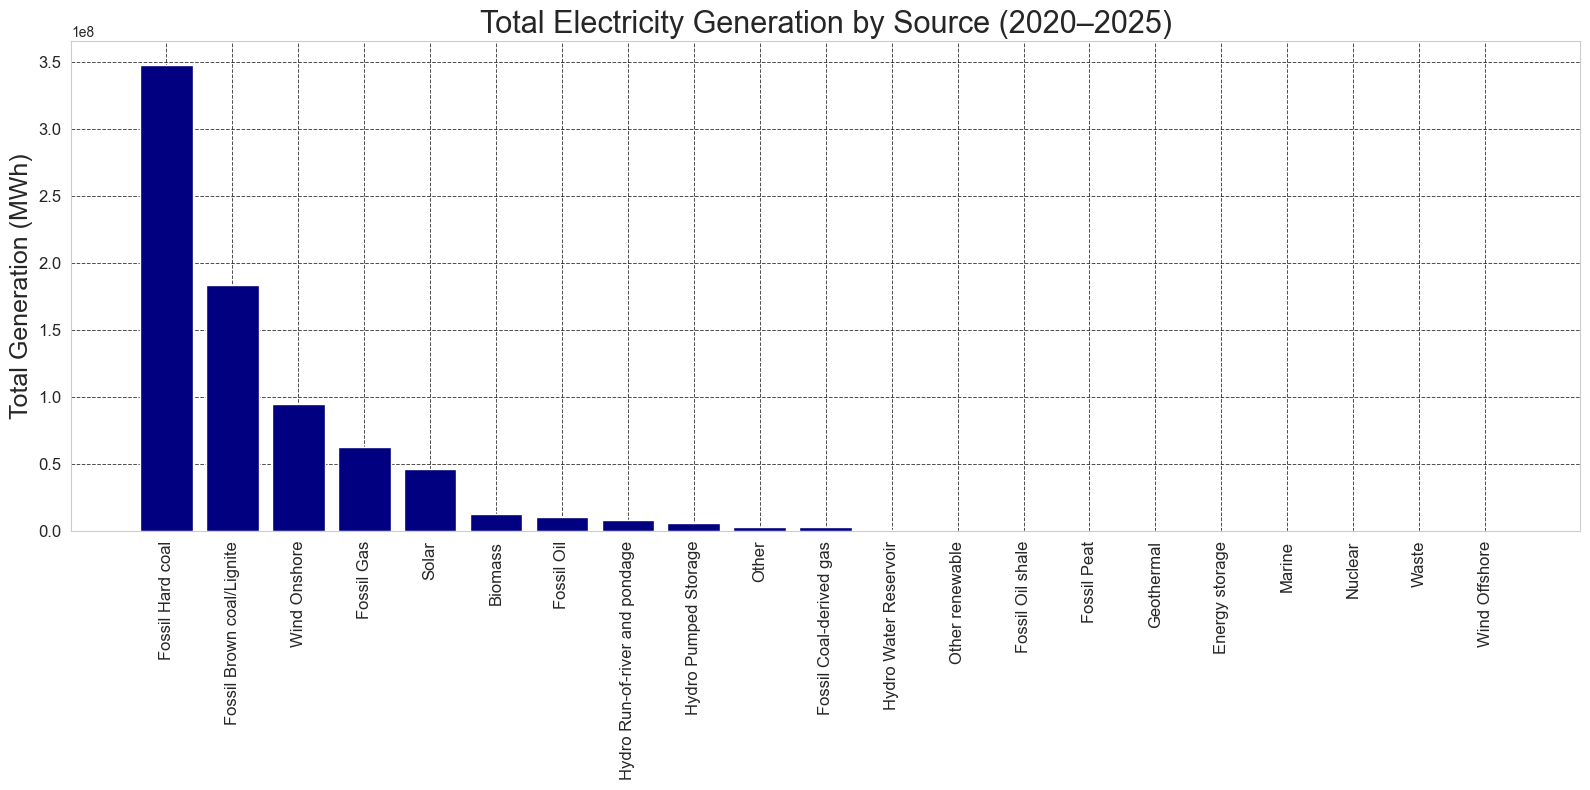

In [50]:
total_gen = generation[numeric_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(16, 8))
plt.bar(total_gen.index, total_gen.values, color='navy')

plt.title('Total Electricity Generation by Source (2020–2025)', fontsize=22)
plt.ylabel('Total Generation (MWh)', fontsize=18)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.7, color='black')
plt.tight_layout()
plt.show()

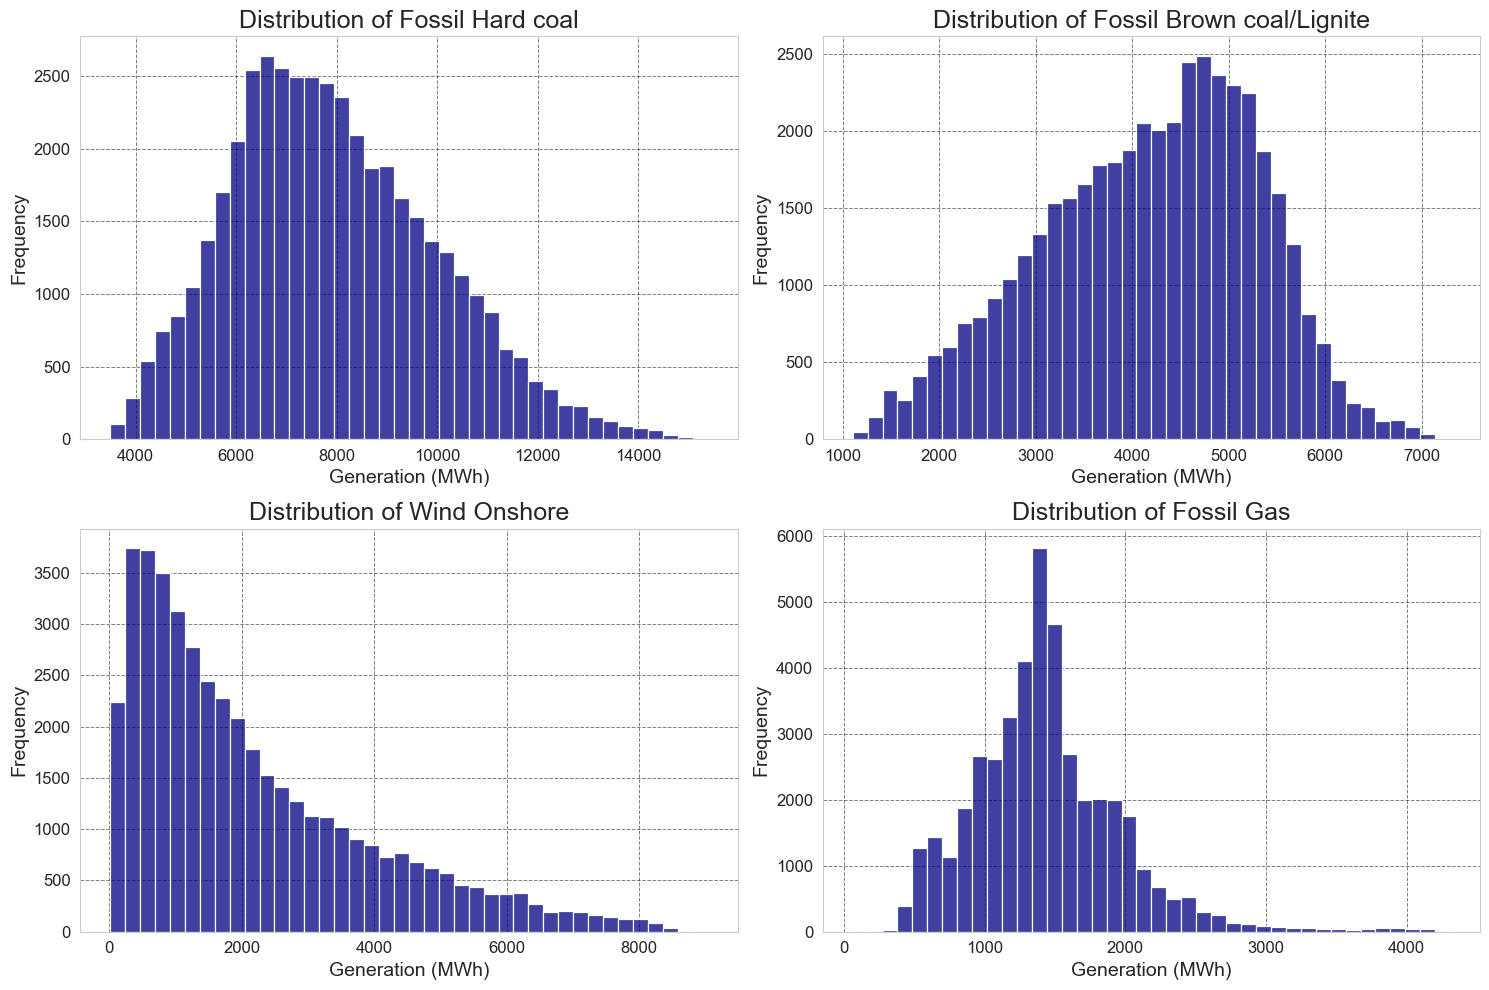

In [57]:
selected = ['Fossil Hard coal', 'Fossil Brown coal/Lignite', 'Wind Onshore', 'Fossil Gas']

plt.figure(figsize=(15, 10))

for i, col in enumerate(selected, 1):
    plt.subplot(2, 2, i)
    sns.histplot(generation[col].dropna(), bins=40, color='navy')
    
    plt.title(f'Distribution of {col}', fontsize=18)
    plt.xlabel('Generation (MWh)', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.5, color='black')

plt.tight_layout()
plt.show()


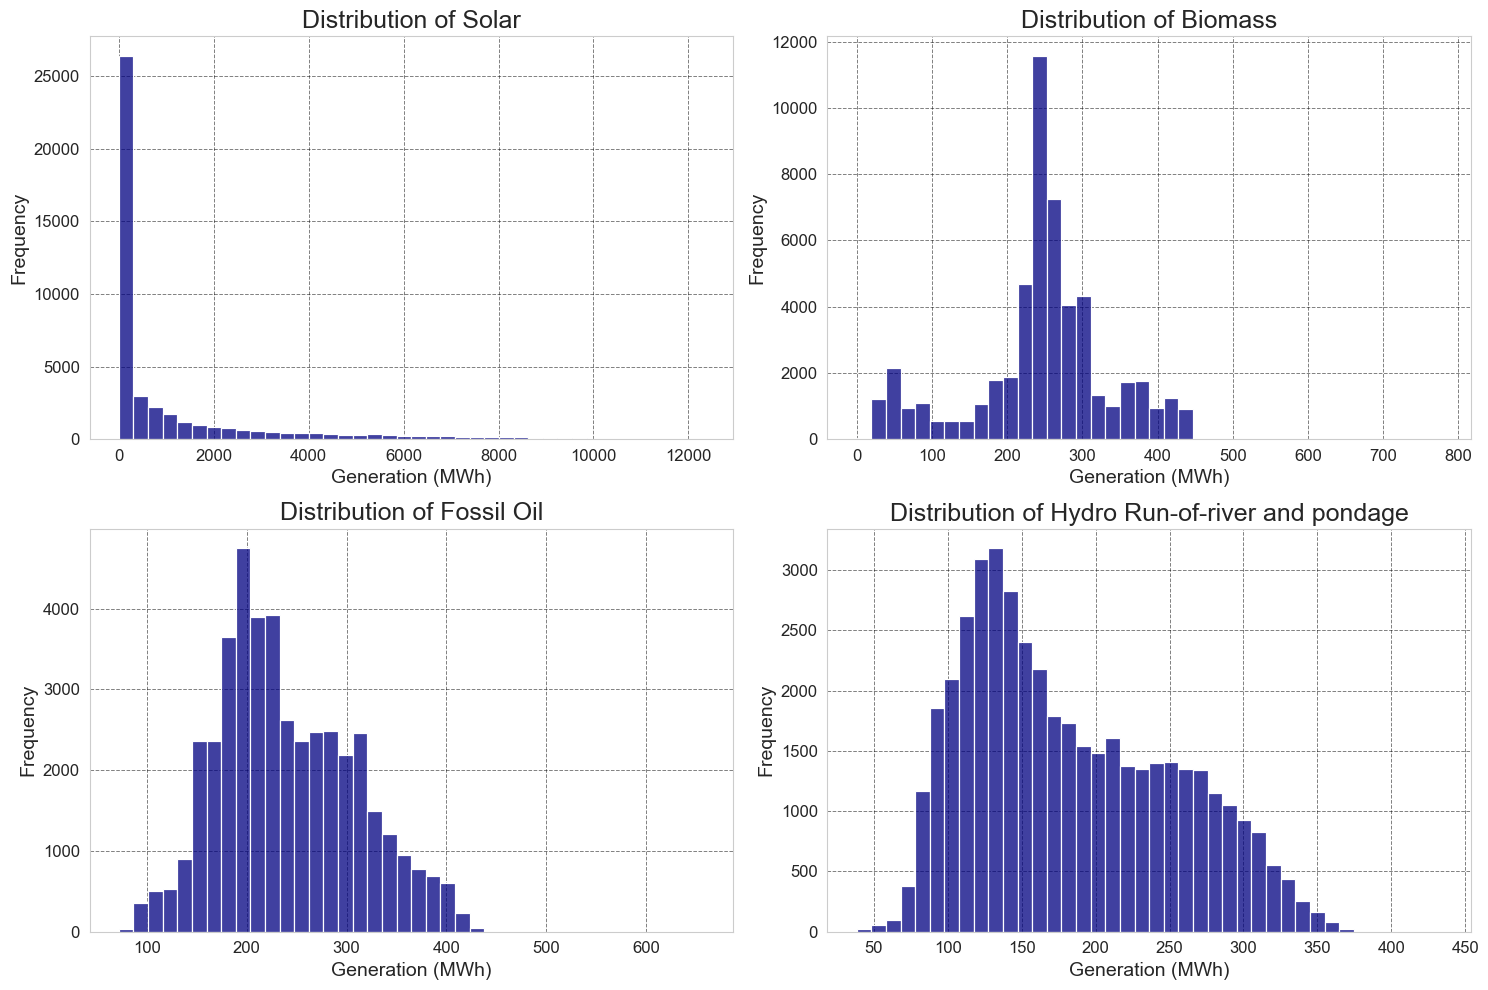

In [56]:
selected = ['Solar', 'Biomass', 'Fossil Oil', 'Hydro Run-of-river and pondage']

plt.figure(figsize=(15, 10))

for i, col in enumerate(selected, 1):
    plt.subplot(2, 2, i)
    sns.histplot(generation[col].dropna(), bins=40, color='navy')
    
    plt.title(f'Distribution of {col}', fontsize=18)
    plt.xlabel('Generation (MWh)', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.5, color='black')

plt.tight_layout()
plt.show()


In [90]:
# renewables = [
#     'Biomass', 'Geothermal', 'Hydro Pumped Storage',
#     'Hydro Run-of-river and pondage', 'Hydro Water Reservoir',
#     'Marine', 'Other renewable', 'Solar', 'Wind Offshore', 'Wind Onshore'
# ]

# fossils = [
#     'Fossil Brown coal/Lignite', 'Fossil Coal-derived gas', 'Fossil Gas',
#     'Fossil Hard coal', 'Fossil Oil', 'Fossil Oil shale', 'Fossil Peat'
# ]

# renew_total = generation[renewables].sum().sum()
# fossil_total = generation[fossils].sum().sum()

# plt.figure(figsize=(12, 6))
# plt.bar(['Renewables', 'Fossils'], [renew_total, fossil_total], color='navy')

# plt.title('Total Renewable vs Fossil Generation (2020–2025)', fontsize=16)
# plt.ylabel('Total Generation (MWh)', fontsize=18)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=12)

# plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.7, color='black')
# plt.tight_layout()
# plt.show()


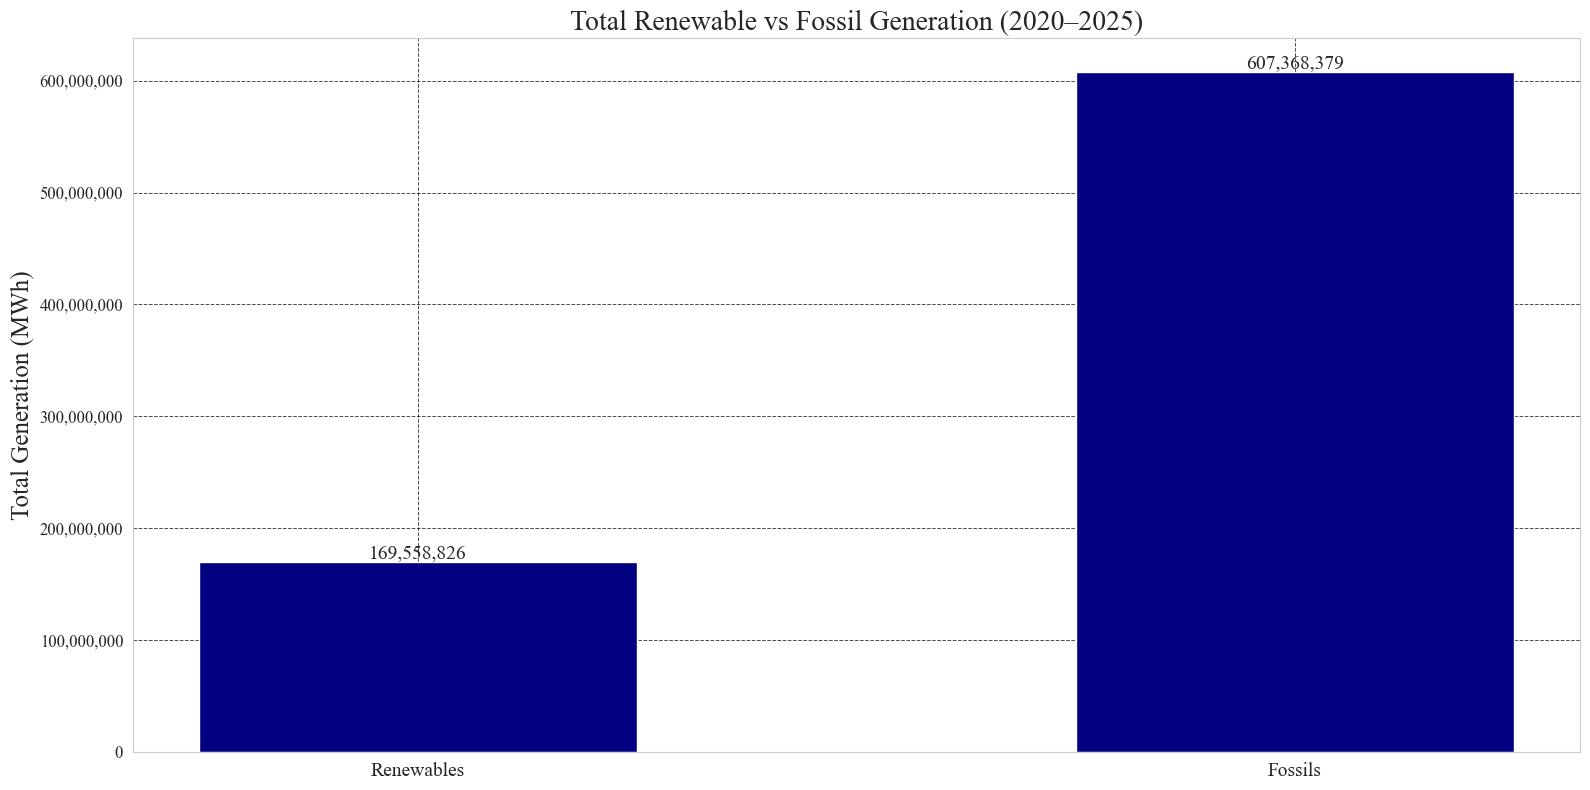

In [95]:
import matplotlib.ticker as ticker

plt.rcParams['font.family'] = 'Times New Roman'

renew_total = generation[renewables].sum().sum()
fossil_total = generation[fossils].sum().sum()

labels = ['Renewables', 'Fossils']
values = [renew_total, fossil_total]

plt.figure(figsize=(16, 8))

# thinner bars → width=0.5
bars = plt.bar(labels, values, color='navy', width=0.5)

plt.title('Total Renewable vs Fossil Generation (2020–2025)', fontsize=20)
plt.ylabel('Total Generation (MWh)', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=12)

# turn off scientific notation
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=14
    )

plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.7, color='black')
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

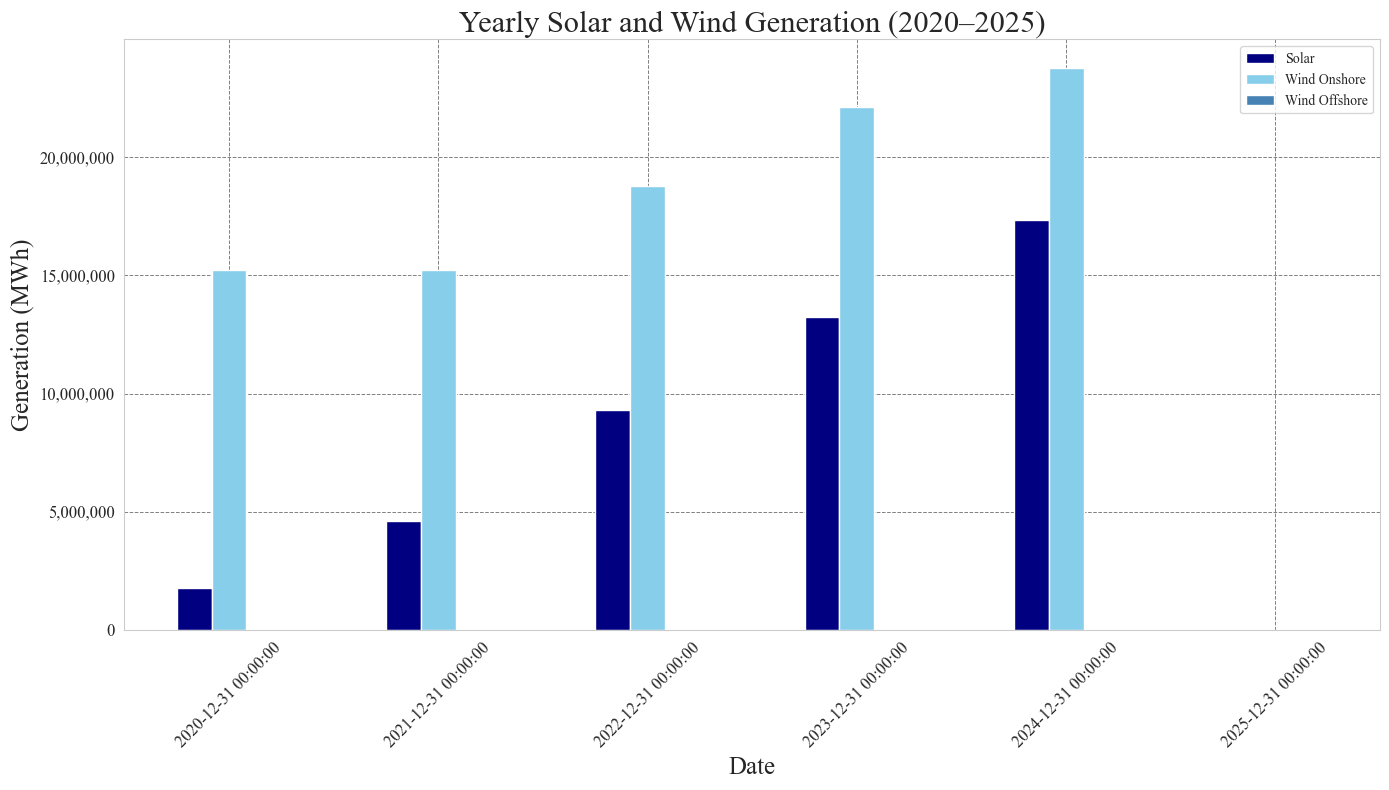

In [108]:
plt.rcParams['font.family'] = 'Times New Roman'

yearly = generation[['Solar', 'Wind Onshore', 'Wind Offshore']].resample('YE').sum()

plt.figure(figsize=(14, 8))
yearly.plot(kind='bar', figsize=(14, 8), color=['navy', 'skyblue', 'steelblue'])

plt.title('Yearly Solar and Wind Generation (2020–2025)', fontsize=22)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Generation (MWh)', fontsize=18)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# turn off scientific notation
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.5, color='black')
plt.tight_layout()
plt.show()


In [106]:
# # Define groups
# renewables = [
#     'Biomass', 'Geothermal', 'Hydro Pumped Storage',
#     'Hydro Run-of-river and pondage', 'Hydro Water Reservoir',
#     'Marine', 'Other renewable', 'Solar', 'Wind Offshore', 'Wind Onshore'
# ]

# fossils = [
#     'Fossil Brown coal/Lignite', 'Fossil Coal-derived gas', 'Fossil Gas',
#     'Fossil Hard coal', 'Fossil Oil', 'Fossil Oil shale', 'Fossil Peat'
# ]

# # Yearly totals
# yearly = generation.resample('YE').sum()

# yearly['Renewables'] = yearly[renewables].sum(axis=1)
# yearly['Fossils'] = yearly[fossils].sum(axis=1)

# # Prepare data
# plot_df = yearly[['Renewables', 'Fossils']]
# plot_df.index = plot_df.index.year  # cleaner x-axis labels

# # Plot
# plt.figure(figsize=(14, 8))

# plt.bar(plot_df.index, plot_df['Fossils'], label='Fossils', color='navy')
# plt.bar(plot_df.index, plot_df['Renewables'], bottom=plot_df['Fossils'],
#         label='Renewables', color='gray')

# plt.title('Yearly Electricity Generation: Renewables vs Fossils (2020–2025)', fontsize=22)
# plt.ylabel('Generation (MWh)', fontsize=18)
# plt.xlabel('Year', fontsize=18)

# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)

# plt.legend(fontsize=16)

# # turn off scientific notation
# plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.5, color='black')
# plt.tight_layout()
# plt.show()

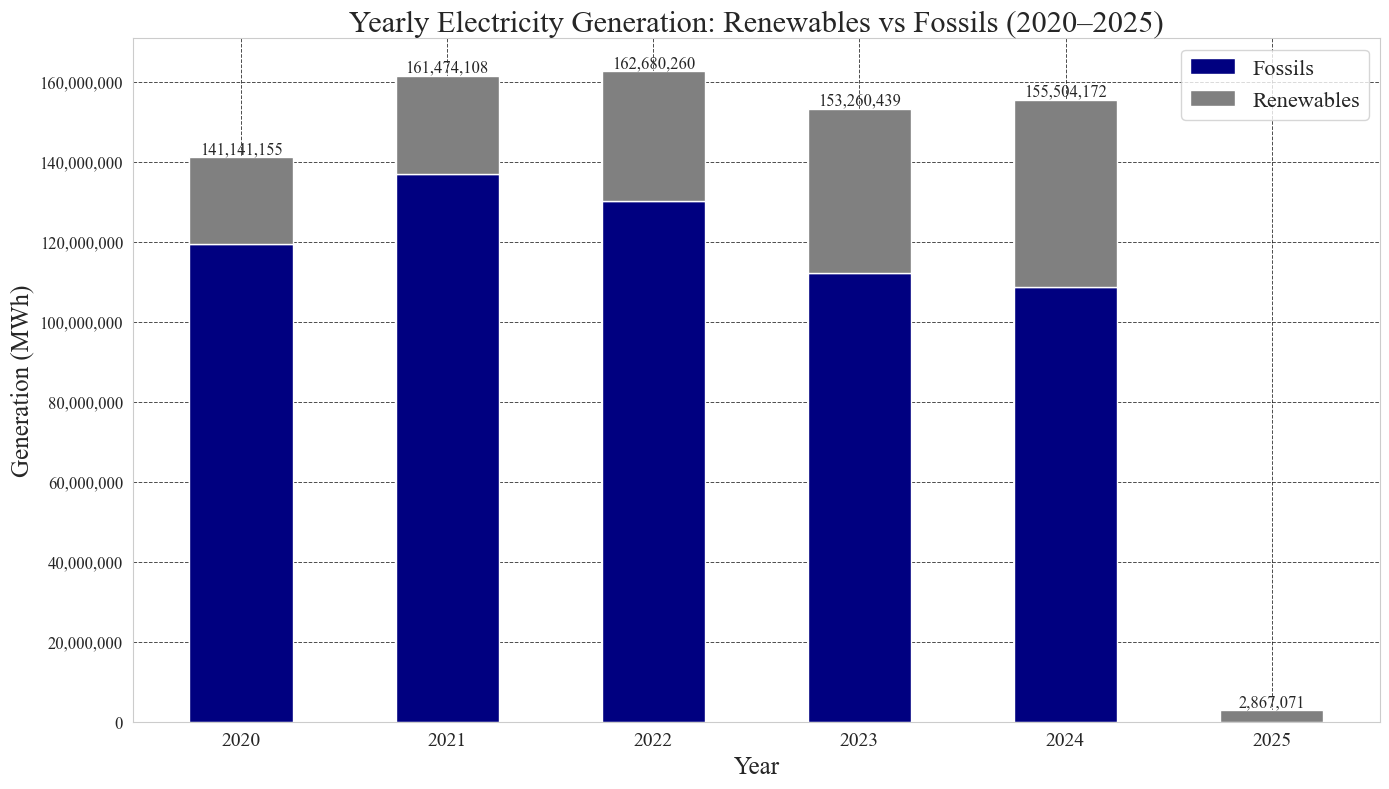

In [109]:
import matplotlib.ticker as ticker

plt.rcParams['font.family'] = 'Times New Roman'

# Define groups
renewables = [
    'Biomass', 'Geothermal', 'Hydro Pumped Storage',
    'Hydro Run-of-river and pondage', 'Hydro Water Reservoir',
    'Marine', 'Other renewable', 'Solar', 'Wind Offshore', 'Wind Onshore'
]

fossils = [
    'Fossil Brown coal/Lignite', 'Fossil Coal-derived gas', 'Fossil Gas',
    'Fossil Hard coal', 'Fossil Oil', 'Fossil Oil shale', 'Fossil Peat'
]

# Yearly totals
yearly = generation.resample('YE').sum()
yearly['Renewables'] = yearly[renewables].sum(axis=1)
yearly['Fossils'] = yearly[fossils].sum(axis=1)

plot_df = yearly[['Renewables', 'Fossils']]
plot_df.index = plot_df.index.year

plt.figure(figsize=(14, 8))

# thinner bars → width=0.5
bars_fossil = plt.bar(plot_df.index, plot_df['Fossils'], 
                      label='Fossils', color='navy', width=0.5)

bars_renew = plt.bar(plot_df.index, plot_df['Renewables'], 
                     bottom=plot_df['Fossils'], label='Renewables', 
                     color='gray', width=0.5)

plt.title('Yearly Electricity Generation: Renewables vs Fossils (2020–2025)', fontsize=22)
plt.ylabel('Generation (MWh)', fontsize=18)
plt.xlabel('Year', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=12)

plt.legend(fontsize=16)

# turn off scientific notation
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

# Add labels on top of the stacked bars
for fossil, renew in zip(bars_fossil, bars_renew):
    total_height = fossil.get_height() + renew.get_height()
    x = fossil.get_x() + fossil.get_width() / 2
    plt.text(x, total_height, f'{total_height:,.0f}',
             ha='center', va='bottom', fontsize=12)

plt.grid(True, linestyle='--', linewidth=0.7, alpha=0.7, color='black')
plt.tight_layout()
plt.show()